- sinusový
- pilový, trojúhelníkový
- obdélníkový
- impulsy

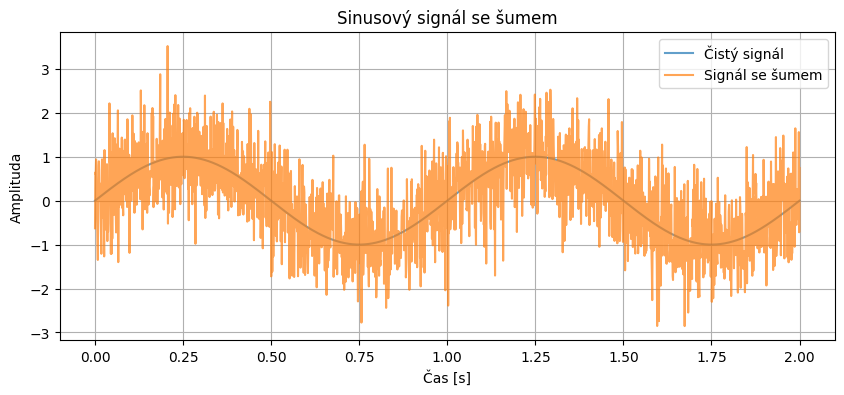

In [33]:
# pomocí definovaných funkcí numpy

import numpy as np
import matplotlib.pyplot as plt

# periodický sinusový signál

def sinus(frekvence, delka, vzorkovaci_frekvence, amplituda=1, faze=0):
    t = np.linspace(0, delka, int(delka * vzorkovaci_frekvence))
    signal = amplituda * np.sin(2 * np.pi * frekvence * t + faze)
    return t, signal

def pridej_sum(signal, uroven_sumu=0.1, typ='normalni'):

    if typ == 'normalni':
        sum = np.random.normal(0, uroven_sumu, len(signal))
    elif typ == 'uniformni':
        sum = np.random.uniform(-uroven_sumu, uroven_sumu, len(signal))
    elif typ == 'bilysum':
        sum = np.random.randn(len(signal)) * uroven_sumu
    
    return signal + sum

# Použití s existující funkcí sinus:
t, y = sinus(frekvence=1, delka=2, vzorkovaci_frekvence=1000)
y_sum = pridej_sum(y, uroven_sumu=0.7)

plt.figure(figsize=(10, 4))
plt.plot(t, y, label='Čistý signál', alpha=0.7)
plt.plot(t, y_sum, label='Signál se šumem', alpha=0.7)
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda')
plt.title('Sinusový signál se šumem')
plt.legend()
plt.grid(True)
plt.show()

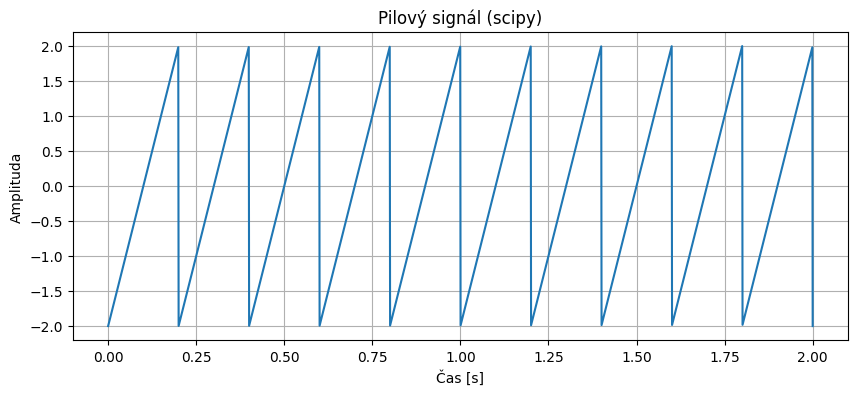

In [11]:
from scipy import signal

def pilovy_scipy(frekvence, delka, vzorkovaci_frekvence, amplituda=1):
    t = np.linspace(0, delka, int(delka * vzorkovaci_frekvence))
    sig = amplituda * signal.sawtooth(2 * np.pi * frekvence * t)
    return t, sig

# Použití:
t, y = pilovy_scipy(frekvence=5, delka=2, vzorkovaci_frekvence=1000, amplituda=2)

plt.figure(figsize=(10, 4))
plt.plot(t, y)
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda')
plt.title('Pilový signál (scipy)')
plt.grid(True)
plt.show()

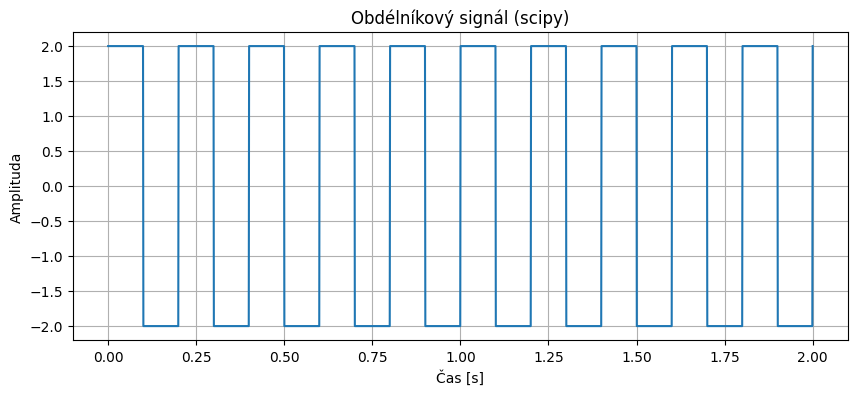

In [12]:
# Obdélníkový signál - způsob 1 (scipy)
from scipy import signal

def obdelnikovy_scipy(frekvence, delka, vzorkovaci_frekvence, amplituda=1, duty_cycle=0.5):
    t = np.linspace(0, delka, int(delka * vzorkovaci_frekvence))
    sig = amplituda * signal.square(2 * np.pi * frekvence * t, duty=duty_cycle)
    return t, sig

# Použití:
t, y = obdelnikovy_scipy(frekvence=5, delka=2, vzorkovaci_frekvence=1000, amplituda=2)

plt.figure(figsize=(10, 4))
plt.plot(t, y)
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda')
plt.title('Obdélníkový signál (scipy)')
plt.grid(True)
plt.show()

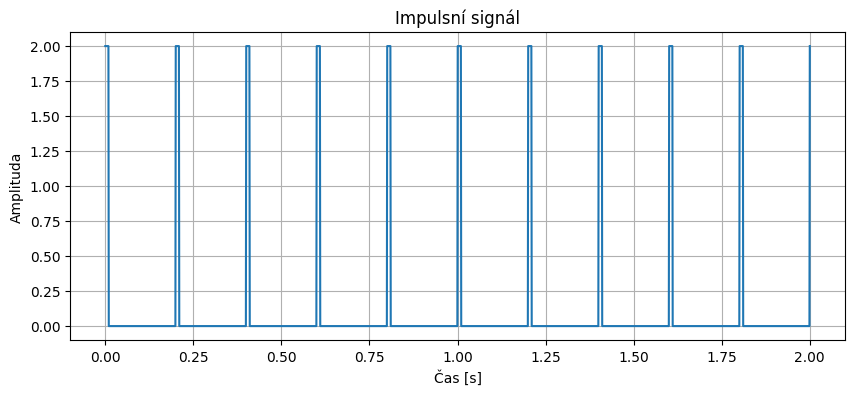

In [13]:
# Impulsní signál - způsob 1 (periodicke impulsy)
def impulsy(frekvence, delka, vzorkovaci_frekvence, amplituda=1, sirka_impulsu=0.01):
    t = np.linspace(0, delka, int(delka * vzorkovaci_frekvence))
    sig = amplituda * np.where((frekvence * t) % 1 < sirka_impulsu, 1, 0)
    return t, sig

# Použití:
t, y = impulsy(frekvence=5, delka=2, vzorkovaci_frekvence=1000, amplituda=2, sirka_impulsu=0.05)

plt.figure(figsize=(10, 4))
plt.plot(t, y)
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda')
plt.title('Impulsní signál')
plt.grid(True)
plt.show()